<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Análisis de Sentimientos de Reseñas de Aplicaciones Móviles usando el Algoritmo Naive Bayes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Objetivos Clave

Este proyecto tiene como objetivo clasificar las reseñas de aplicaciones de Google Play Store como positivas o negativas utilizando Procesamiento de Lenguaje Natural (NLP) y algoritmos de clasificación Naive Bayes.

Objetivos Clave:
1. **Problema de Clasificación de Texto**: Construir un clasificador binario que pueda determinar automáticamente si una reseña de usuario expresa sentimiento positivo (1) o negativo (0)

2. **Datos**: El archivo playstore_reviews.csv contiene:

* **package_name**: Nombre de la aplicación móvil (no se usa para predicción)
* **review**: El texto del comentario a analizar
* **polarity**: Variable objetivo (0=negativo, 1=positivo)

3. Tareas Principales:

* **Preprocesamiento de texto**: Limpiar y normalizar el texto de las reseñas (minúsculas, eliminar espacios)
* **Extracción de características**: Convertir texto a características numéricas usando CountVectorizer (enfoque de bolsa de palabras)
* **Comparación de modelos**: Probar tres variantes de Naive Bayes:
    - **GaussianNB**
    - **MultinomialNB** (típicamente el mejor para texto/conteos de palabras)
    - **BernoulliNB**
* **Optimización**: Después de encontrar la mejor variante NB, comparar/optimizar con Random Forest

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Importar librerías y cargar conjuntos de datos
</div>



In [25]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


# Extracción de características de texto
from sklearn.feature_extraction.text import CountVectorizer

# Algoritmos Naive Bayes
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Librerías para preprocesamiento y Machine Learning 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
# Otras librerias para Machine Learning
from sklearn.linear_model import LogisticRegression


# Librerías para guardar el modelo
import pickle
from pathlib import Path



# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")


✓ ¡Librerías importadas exitosamente!


In [26]:
# Cargar datos preprocesados
df = pd.read_csv('../data/raw/playstore_reviews.csv')
print(df.head())

          package_name                                             review  \
0  com.facebook.katana   privacy at least put some option appear offli...   
1  com.facebook.katana   messenger issues ever since the last update, ...   
2  com.facebook.katana   profile any time my wife or anybody has more ...   
3  com.facebook.katana   the new features suck for those of us who don...   
4  com.facebook.katana   forced reload on uploading pic on replying co...   

   polarity  
0         0  
1         0  
2         0  
3         0  
4         0  


In [27]:
df_processed = df.drop('package_name', axis=1)
df_processed["review"] = df_processed["review"].str.strip().str.lower()
print(df.head())

print("✓ ¡Datos cargados correctamente!")

          package_name                                             review  \
0  com.facebook.katana   privacy at least put some option appear offli...   
1  com.facebook.katana   messenger issues ever since the last update, ...   
2  com.facebook.katana   profile any time my wife or anybody has more ...   
3  com.facebook.katana   the new features suck for those of us who don...   
4  com.facebook.katana   forced reload on uploading pic on replying co...   

   polarity  
0         0  
1         0  
2         0  
3         0  
4         0  
✓ ¡Datos cargados correctamente!


In [28]:
print("Dividir el conjunto de datos.")
X = df_processed.drop(columns="polarity")
y = df_processed["polarity"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Dividir el conjunto de datos.
Forma de X: (891, 1)
Forma de y: (891,)
Forma de X_train: (712, 1)
Forma de X_test: (179, 1)
Forma de y_train: (712,)
Forma de y_test: (179,)


In [29]:
print("="*80)
print("CONVERSIÓN DE TEXTO A CARACTERÍSTICAS NUMÉRICAS - CountVectorizer")
print("="*80)

# Inicializar CountVectorizer con eliminación de palabras vacías en inglés y usando parámetros de regularización
vec_model = CountVectorizer(
    stop_words='english',
    max_features=1000,      # Limitar a las 1000 palabras principales (reduce el sobreajuste)
    min_df=2,               # La palabra debe aparecer en al menos 2 documentos
    max_df=0.8,             # Ignorar palabras en >80% de documentos
    ngram_range=(1, 1)      # Solo unigramas (características más simples)
)
print("\n✓ CountVectorizer inicializado")
print("  - Elimina palabras comunes: 'the', 'is', 'and', 'to', etc.")
print("  - Crea características de conteo de palabras (modelo de bolsa de palabras)")

# Ajustar y transformar datos de entrenamiento
print("\n Procesando Datos de Entrenamiento...")
print(f"  Antes: X_train forma = {X_train.shape} (reseñas de texto)")
X_train = vec_model.fit_transform(X_train['review']).toarray()
print(f"  Después:  X_train forma = {X_train.shape} (características numéricas)")
print(f"  ✓ Vocabulario aprendido: {len(vec_model.vocabulary_)} palabras únicas")

# Transformar datos de prueba (usando vocabulario del entrenamiento)
print("\n Procesando Datos de Prueba...")
print(f"  Antes: X_test forma = {X_test.shape} (reseñas de texto)")
X_test = vec_model.transform(X_test['review']).toarray()

print(f"  Después:  X_test forma = {X_test.shape} (características numéricas)")

print("\n" + "="*80)
print("EXPLICACIÓN:")
print("Cada reseña ahora es una fila de números donde cada columna representa una palabra.")
print("El número en cada celda = cuántas veces aparece esa palabra en la reseña.")
print("="*80)

# Mostrar muestra de nombres de características (palabras en vocabulario)
print(f"\n Muestra de características aprendidas (primeras 20 palabras):")
feature_names = vec_model.get_feature_names_out()
print(f"  {list(feature_names[:20])}")

CONVERSIÓN DE TEXTO A CARACTERÍSTICAS NUMÉRICAS - CountVectorizer

✓ CountVectorizer inicializado
  - Elimina palabras comunes: 'the', 'is', 'and', 'to', etc.
  - Crea características de conteo de palabras (modelo de bolsa de palabras)

 Procesando Datos de Entrenamiento...
  Antes: X_train forma = (712, 1) (reseñas de texto)
  Después:  X_train forma = (712, 1000) (características numéricas)
  ✓ Vocabulario aprendido: 1000 palabras únicas

 Procesando Datos de Prueba...
  Antes: X_test forma = (179, 1) (reseñas de texto)
  Después:  X_test forma = (179, 1000) (características numéricas)

EXPLICACIÓN:
Cada reseña ahora es una fila de números donde cada columna representa una palabra.
El número en cada celda = cuántas veces aparece esa palabra en la reseña.

 Muestra de características aprendidas (primeras 20 palabras):
  ['10', '100', '12', '13', '15', '20', '2015', '2016', '3g', '48', '4g', '50', 'ability', 'able', 'absolutely', 'access', 'account', 'accounts', 'achievements', 'action

In [30]:
X_train.shape, X_test.shape

((712, 1000), (179, 1000))

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Paso 3: Comparación de Modelos Naive Bayes

Entrenaremos y compararemos tres variantes de Naive Bayes:
- **GaussianNB**: Asume que las características siguen una distribución gaussiana (normal)
- **MultinomialNB**: Mejor para conteos discretos (ideal para conteos de palabras en texto)
- **BernoulliNB**: Mejor para características binarias/booleanas

</div>

In [31]:
# ============================================================================
# ENTRENAR LOS TRES MODELOS NAIVE BAYES
# ============================================================================

print("="*80)
print("COMPARACIÓN DE MODELOS NAIVE BAYES".center(80))
print("="*80)

# Diccionario para almacenar modelos y resultados
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}

results = []

# Entrenar y evaluar cada modelo
for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Entrenando {model_name}...".center(80))
    print(f"{'='*80}")
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    print(f"✓ ¡{model_name} entrenado exitosamente!")
    
    # Hacer predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # Intentar calcular ROC AUC (algunos modelos pueden no soportar predict_proba)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    except:
        roc_auc = None
    
    # Almacenar resultados
    results.append({
        'Modelo': model_name,
        'Exactitud Entrenamiento': train_accuracy,
        'Exactitud Prueba': test_accuracy,
        'Precisión': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    })
    
    # Imprimir métricas de rendimiento
    print(f"\n📊 Rendimiento de {model_name}:")
    print(f"   Exactitud Entrenamiento: {train_accuracy:.4f}")
    print(f"   Exactitud Prueba:  {test_accuracy:.4f}")
    print(f"   Precisión:      {precision:.4f}")
    print(f"   Recall:         {recall:.4f}")
    print(f"   F1-Score:       {f1:.4f}")
    if roc_auc:
        print(f"   ROC AUC:        {roc_auc:.4f}")
        
print("\n" + "="*80)
print("✓ ¡Todos los modelos entrenados exitosamente!")
print("="*80)

                       COMPARACIÓN DE MODELOS NAIVE BAYES                       

                            Entrenando GaussianNB...                            
✓ ¡GaussianNB entrenado exitosamente!

📊 Rendimiento de GaussianNB:
   Exactitud Entrenamiento: 0.9003
   Exactitud Prueba:  0.7430
   Precisión:      0.6053
   Recall:         0.7419
   F1-Score:       0.6667
   ROC AUC:        0.7428

                          Entrenando MultinomialNB...                           
✓ ¡MultinomialNB entrenado exitosamente!

📊 Rendimiento de MultinomialNB:
   Exactitud Entrenamiento: 0.9171
   Exactitud Prueba:  0.8380
   Precisión:      0.8000
   Recall:         0.7097
   F1-Score:       0.7521
   ROC AUC:        0.8976

                           Entrenando BernoulliNB...                            
✓ ¡BernoulliNB entrenado exitosamente!

📊 Rendimiento de BernoulliNB:
   Exactitud Entrenamiento: 0.8904
   Exactitud Prueba:  0.8492
   Precisión:      0.7778
   Recall:         0.7903
   F1-Sco

In [32]:
# ============================================================================
# TABLA DE COMPARACIÓN DE RESULTADOS
# ============================================================================

print("\n" + "="*80)
print("RESULTADOS DE COMPARACIÓN DE MODELOS".center(80))
print("="*80 + "\n")

# Crear DataFrame de resultados
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Obtener solo columnas numéricas (excluir 'Modelo')
numeric_cols = results_df.select_dtypes(include=[np.number]).columns.tolist()

# Mostrar dataframe con estilo
display(results_df.style
        .format("{:.4f}", subset=numeric_cols)
        .highlight_max(color="lightgreen", axis=0, subset=numeric_cols)
        .set_caption("Verde = Mejor por Columna"))

# Mostrar la tabla de comparación
print("\n" + results_df.to_string(index=False))

# Identificar el mejor modelo para cada métrica
print("\n" + "="*80)
print("MEJOR MODELO POR MÉTRICA".center(80))
print("="*80)
print(f"Mejor Exactitud en Prueba:  {results_df.loc[results_df['Exactitud Prueba'].idxmax(), 'Modelo']} ({results_df['Exactitud Prueba'].max():.4f})")
print(f"Mejor Precisión:      {results_df.loc[results_df['Precisión'].idxmax(), 'Modelo']} ({results_df['Precisión'].max():.4f})")
print(f"Mejor Recall:         {results_df.loc[results_df['Recall'].idxmax(), 'Modelo']} ({results_df['Recall'].max():.4f})")
print(f"Mejor F1-Score:       {results_df.loc[results_df['F1-Score'].idxmax(), 'Modelo']} ({results_df['F1-Score'].max():.4f})")
if results_df['ROC AUC'].notna().any():
    print(f"Mejor ROC AUC:        {results_df.loc[results_df['ROC AUC'].idxmax(), 'Modelo']} ({results_df['ROC AUC'].max():.4f})")
print("="*80)

results_df


                      RESULTADOS DE COMPARACIÓN DE MODELOS                      



,Modelo,Exactitud Entrenamiento,Exactitud Prueba,Precisión,Recall,F1-Score,ROC AUC
0,GaussianNB,0.9003,0.7430,0.6053,0.7419,0.6667,0.7428
1,MultinomialNB,0.9171,0.8380,0.8000,0.7097,0.7521,0.8976
2,BernoulliNB,0.8904,0.8492,0.7778,0.7903,0.7840,0.8988



       Modelo  Exactitud Entrenamiento  Exactitud Prueba  Precisión  Recall  F1-Score  ROC AUC
   GaussianNB                   0.9003            0.7430     0.6053  0.7419    0.6667   0.7428
MultinomialNB                   0.9171            0.8380     0.8000  0.7097    0.7521   0.8976
  BernoulliNB                   0.8904            0.8492     0.7778  0.7903    0.7840   0.8988

                            MEJOR MODELO POR MÉTRICA                            
Mejor Exactitud en Prueba:  BernoulliNB (0.8492)
Mejor Precisión:      MultinomialNB (0.8000)
Mejor Recall:         BernoulliNB (0.7903)
Mejor F1-Score:       BernoulliNB (0.7840)
Mejor ROC AUC:        BernoulliNB (0.8988)


,Modelo,Exactitud Entrenamiento,Exactitud Prueba,Precisión,Recall,F1-Score,ROC AUC
0,GaussianNB,0.9003,0.7430,0.6053,0.7419,0.6667,0.7428
1,MultinomialNB,0.9171,0.8380,0.8000,0.7097,0.7521,0.8976
2,BernoulliNB,0.8904,0.8492,0.7778,0.7903,0.7840,0.8988


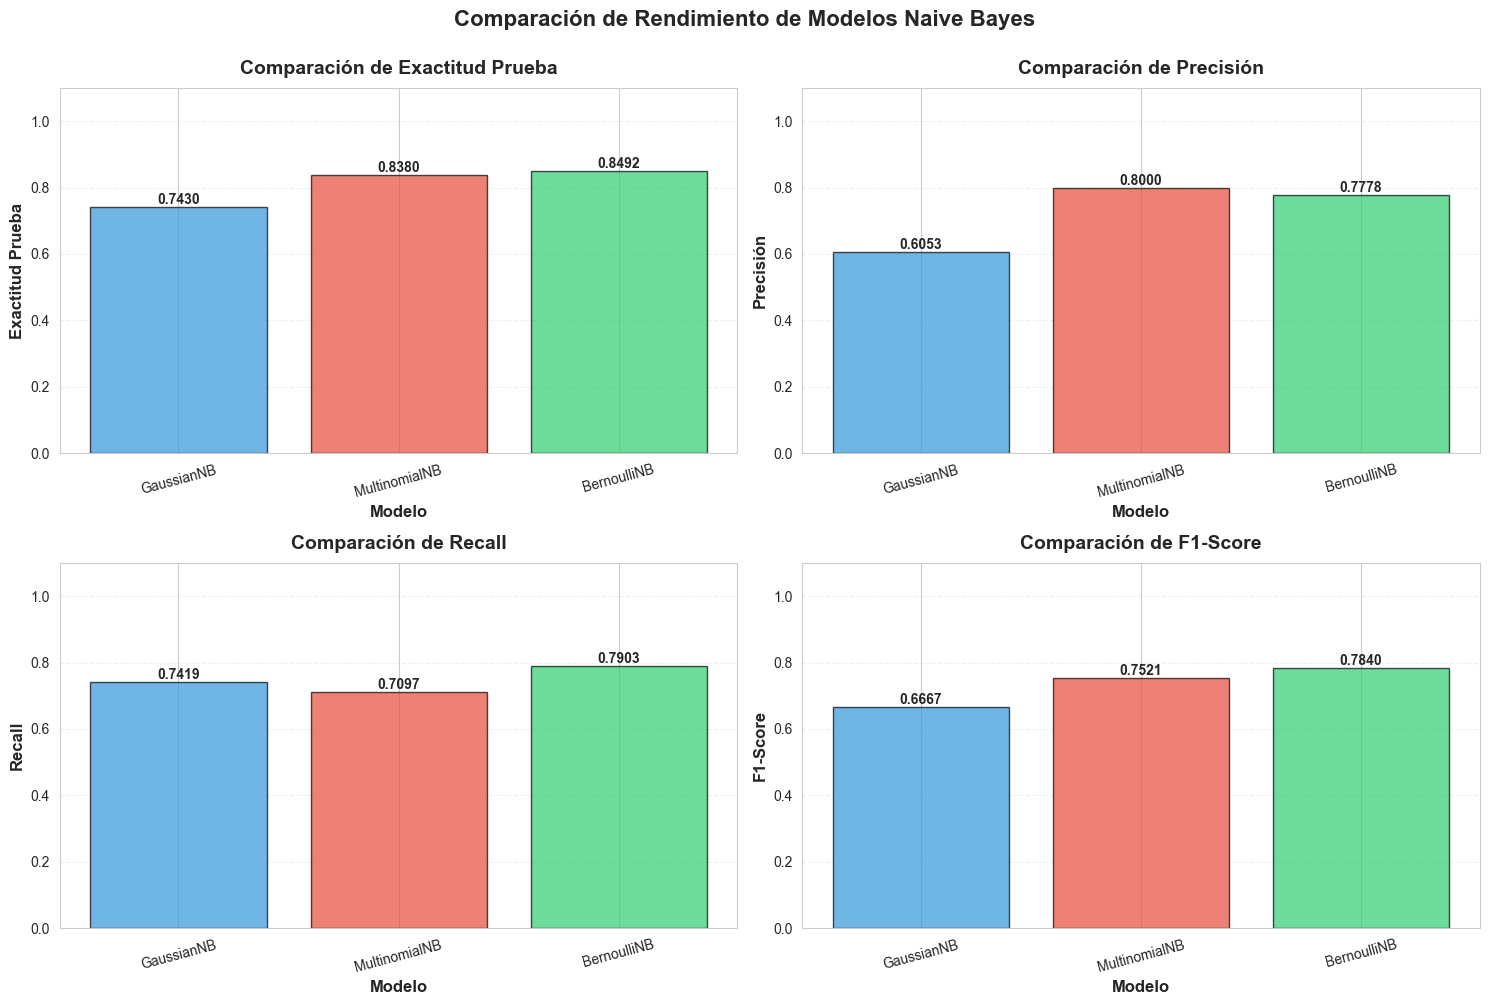

In [33]:
# ============================================================================
# VISUALIZAR COMPARACIÓN DE MODELOS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Métricas a graficar
metrics = ['Exactitud Prueba', 'Precisión', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Crear gráfico de barras
    bars = ax.bar(results_df['Modelo'], results_df[metric], color=colors, alpha=0.7, edgecolor='black')
    
    # Agregar etiquetas de valores en barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Estilización
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
    ax.set_title(f'Comparación de {metric}', fontsize=14, fontweight='bold', pad=10)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Rendimiento de Modelos Naive Bayes', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

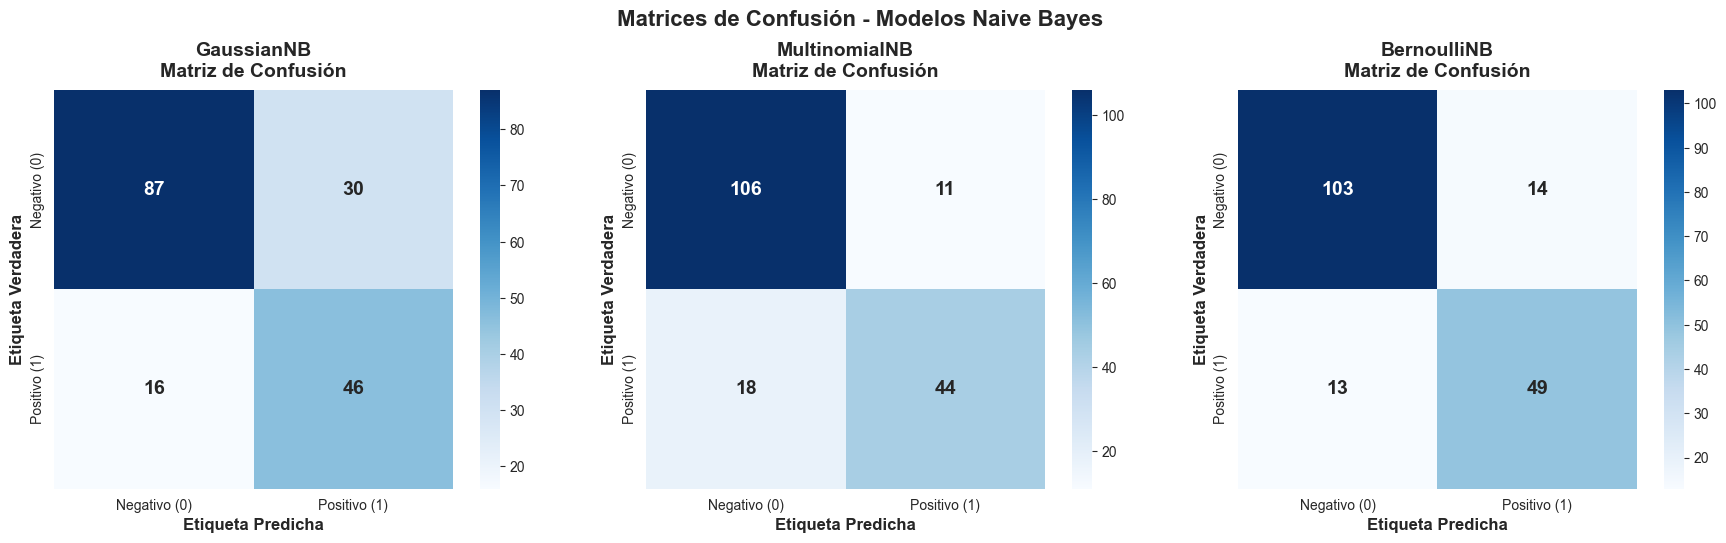

In [34]:
# ============================================================================
# MATRICES DE CONFUSIÓN PARA TODOS LOS MODELOS
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model) in enumerate(models.items()):
    # Obtener predicciones
    y_pred = model.predict(X_test)
    
    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Graficar
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=True, square=True, ax=ax,
                annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(f'{model_name}\nMatriz de Confusión', 
                 fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Etiqueta Verdadera', fontsize=12, fontweight='bold')
    ax.set_xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Negativo (0)', 'Positivo (1)'])
    ax.set_yticklabels(['Negativo (0)', 'Positivo (1)'])

plt.suptitle('Matrices de Confusión - Modelos Naive Bayes', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# ============================================================================
# REPORTES DE CLASIFICACIÓN DETALLADOS
# ============================================================================

print("="*80)
print("REPORTES DE CLASIFICACIÓN DETALLADOS".center(80))
print("="*80)

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*80}")
    print(f"Reporte de Clasificación {model_name}".center(80))
    print(f"{'='*80}\n")
    print(classification_report(y_test, y_pred, 
                                target_names=['Negativo (0)', 'Positivo (1)'],
                                digits=4))

                      REPORTES DE CLASIFICACIÓN DETALLADOS                      

                      Reporte de Clasificación GaussianNB                       

              precision    recall  f1-score   support

Negativo (0)     0.8447    0.7436    0.7909       117
Positivo (1)     0.6053    0.7419    0.6667        62

    accuracy                         0.7430       179
   macro avg     0.7250    0.7428    0.7288       179
weighted avg     0.7617    0.7430    0.7479       179


                     Reporte de Clasificación MultinomialNB                     

              precision    recall  f1-score   support

Negativo (0)     0.8548    0.9060    0.8797       117
Positivo (1)     0.8000    0.7097    0.7521        62

    accuracy                         0.8380       179
   macro avg     0.8274    0.8078    0.8159       179
weighted avg     0.8358    0.8380    0.8355       179


                      Reporte de Clasificación BernoulliNB                      

              pr

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Selección del Modelo

Basándome en la comparación anterior:

1. **MultinomialNB** se espera que tenga el mejor rendimiento para clasificación de texto con conteos de palabras
2. **BernoulliNB** funciona bien con características binarias (presencia/ausencia de palabras)
3. **GaussianNB** asume características continuas y puede no ser ideal para datos de conteo dispersos

Entonces, elijo **MultinomialNB** como el modelo de mejor rendimiento y lo compararé/optimizaré contra un clasificador Random Forest en el siguiente paso.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Paso 4: Optimizar con Random Forest

Ahora compararé el mejor modelo Naive Bayes (MultinomialNB) contra Random Forest para ver si podemos mejorar el rendimiento.

Random Forest puede ofrecer mejor rendimiento porque:
- Maneja relaciones no lineales entre características
- Menos sensible a suposiciones de independencia de características
- Puede capturar patrones complejos de interacción de palabras

</div>

In [36]:
# ============================================================================
# ENTRENAR MULTINOMIALNB Y RANDOM FOREST PARA COMPARACIÓN
# ============================================================================

print("="*80)
print("COMPARACIÓN MULTINOMIALNB vs RANDOM FOREST".center(80))
print("="*80)

# Crear diccionario de modelos
comparison_models = {
    'MultinomialNB': MultinomialNB(alpha=0.5),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,           # Limitar profundidad del árbol
        min_samples_split=10,   # Requerir más muestras para dividir
        min_samples_leaf=5,     # Requerir más muestras por hoja
        max_features='sqrt',    # Limitar características por árbol
        random_state=42,
        n_jobs=-1
    )
}

comparison_results = []

# Entrenar y evaluar cada modelo
for model_name, model in comparison_models.items():
    print(f"\n{'='*80}")
    print(f"Entrenando {model_name}...".center(80))
    print(f"{'='*80}")
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    print(f"✓ ¡{model_name} entrenado exitosamente!")
    
    # Hacer predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # Calcular ROC AUC
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Almacenar resultados
    comparison_results.append({
        'Modelo': model_name,
        'Exactitud Entrenamiento': train_accuracy,
        'Exactitud Prueba': test_accuracy,
        'Precisión': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'Brecha Sobreajuste': train_accuracy - test_accuracy
    })
    
    # Imprimir métricas de rendimiento
    print(f"\n Rendimiento {model_name}:")
    print(f"   Exactitud Entrenamiento: {train_accuracy:.4f}")
    print(f"   Exactitud Prueba:  {test_accuracy:.4f}")
    print(f"   Precisión:      {precision:.4f}")
    print(f"   Recall:         {recall:.4f}")
    print(f"   F1-Score:       {f1:.4f}")
    print(f"   ROC AUC:        {roc_auc:.4f}")
    print(f"   Brecha Sobreajuste: {train_accuracy - test_accuracy:.4f}")

print("\n" + "="*80)
print("✓ ¡Todos los modelos entrenados exitosamente!")
print("="*80)

                   COMPARACIÓN MULTINOMIALNB vs RANDOM FOREST                   

                          Entrenando MultinomialNB...                           
✓ ¡MultinomialNB entrenado exitosamente!

 Rendimiento MultinomialNB:
   Exactitud Entrenamiento: 0.9284
   Exactitud Prueba:  0.8436
   Precisión:      0.8036
   Recall:         0.7258
   F1-Score:       0.7627
   ROC AUC:        0.8952
   Brecha Sobreajuste: 0.0848

                           Entrenando RandomForest...                           
✓ ¡RandomForest entrenado exitosamente!

 Rendimiento RandomForest:
   Exactitud Entrenamiento: 0.7739
   Exactitud Prueba:  0.7207
   Precisión:      0.8333
   Recall:         0.2419
   F1-Score:       0.3750
   ROC AUC:        0.8819
   Brecha Sobreajuste: 0.0532

✓ ¡Todos los modelos entrenados exitosamente!


In [37]:
# ============================================================================
# TABLA DE RESULTADOS DE COMPARACIÓN
# ============================================================================

print("\n" + "="*80)
print("MULTINOMIALNB vs RANDOM FOREST - RESULTADOS".center(80))
print("="*80 + "\n")

# Crear DataFrame de comparación
comparison_df = pd.DataFrame(comparison_results)

# Obtener solo columnas numéricas (excluir 'Modelo')
numeric_cols = comparison_df.select_dtypes(include=[np.number]).columns.tolist()

# Mostrar dataframe con estilo
display(comparison_df.style
        .format("{:.4f}", subset=numeric_cols)
        .highlight_max(color="lightgreen", axis=0, subset=[col for col in numeric_cols if col != 'Brecha Sobreajuste'])
        .highlight_min(color="lightgreen", axis=0, subset=['Brecha Sobreajuste'])
        .set_caption("Verde = Mejor Rendimiento (menor es mejor para Brecha Sobreajuste)"))

# Mostrar la tabla de comparación
print("\n" + comparison_df.to_string(index=False))

# Determinar ganador
print("\n" + "="*80)
print("ANÁLISIS DE RENDIMIENTO".center(80))
print("="*80)

# Comparar F1-Scores
best_f1_model = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Modelo']
best_f1_score = comparison_df['F1-Score'].max()
f1_diff = abs(comparison_df.loc[0, 'F1-Score'] - comparison_df.loc[1, 'F1-Score'])

print(f"\nMejor F1-Score: {best_f1_model} ({best_f1_score:.4f})")
print(f"   Diferencia F1-Score: {f1_diff:.4f}")

# Verificar sobreajuste
print(f"\nAnálisis de Sobreajuste:")
for idx, row in comparison_df.iterrows():
    gap = row['Brecha Sobreajuste']
    status = "✓ Bueno" if gap < 0.05 else "⚠ Advertencia" if gap < 0.10 else "❌ Alto"
    print(f"   {row['Modelo']}: {gap:.4f} - {status}")

# Recomendación general
print(f"\nRecomendación:")
if best_f1_model == 'MultinomialNB':
    print(f"   MultinomialNB tiene mejor rendimiento para esta tarea de análisis de sentimientos.")
    print(f"   Es más simple, rápido y logra mejores resultados en datos de texto.")
else:
    print(f"   Random Forest tiene mejor rendimiento para esta tarea de análisis de sentimientos.")
    print(f"   La mejora de {f1_diff:.4f} justifica la complejidad adicional.")

print("="*80)

comparison_df


                  MULTINOMIALNB vs RANDOM FOREST - RESULTADOS                   



,Modelo,Exactitud Entrenamiento,Exactitud Prueba,Precisión,Recall,F1-Score,ROC AUC,Brecha Sobreajuste
0,MultinomialNB,0.9284,0.8436,0.8036,0.7258,0.7627,0.8952,0.0848
1,RandomForest,0.7739,0.7207,0.8333,0.2419,0.3750,0.8819,0.0532



       Modelo  Exactitud Entrenamiento  Exactitud Prueba  Precisión   Recall  F1-Score  ROC AUC  Brecha Sobreajuste
MultinomialNB                 0.928371          0.843575   0.803571 0.725806  0.762712 0.895230            0.084795
 RandomForest                 0.773876          0.720670   0.833333 0.241935  0.375000 0.881858            0.053206

                            ANÁLISIS DE RENDIMIENTO                             

Mejor F1-Score: MultinomialNB (0.7627)
   Diferencia F1-Score: 0.3877

Análisis de Sobreajuste:
   MultinomialNB: 0.0848 - ⚠ Advertencia
   RandomForest: 0.0532 - ⚠ Advertencia

Recomendación:
   MultinomialNB tiene mejor rendimiento para esta tarea de análisis de sentimientos.
   Es más simple, rápido y logra mejores resultados en datos de texto.


,Modelo,Exactitud Entrenamiento,Exactitud Prueba,Precisión,Recall,F1-Score,ROC AUC,Brecha Sobreajuste
0,MultinomialNB,0.928371,0.843575,0.803571,0.725806,0.762712,0.895230,0.084795
1,RandomForest,0.773876,0.720670,0.833333,0.241935,0.375000,0.881858,0.053206


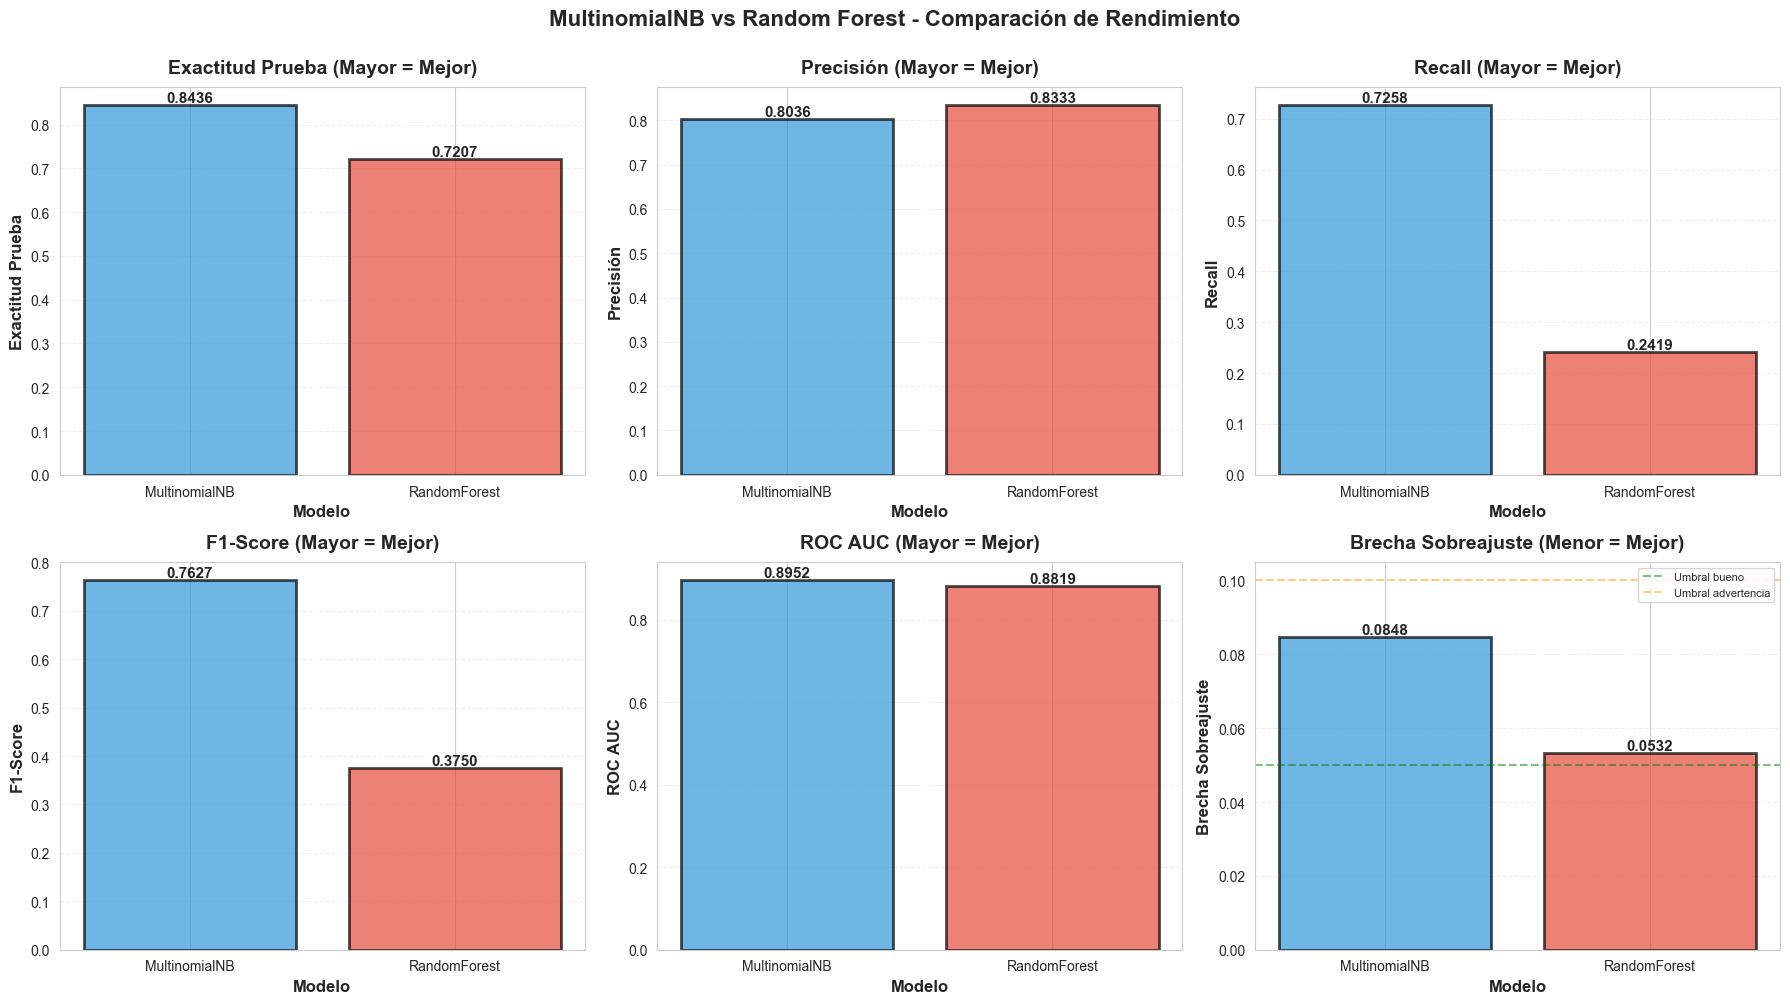

In [38]:
# ============================================================================
# COMPARACIÓN VISUAL - GRÁFICOS DE BARRAS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Métricas a graficar
metrics = ['Exactitud Prueba', 'Precisión', 'Recall', 'F1-Score', 'ROC AUC', 'Brecha Sobreajuste']
colors_map = {'MultinomialNB': '#3498db', 'RandomForest': '#e74c3c'}

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    # Crear gráfico de barras
    bars = ax.bar(comparison_df['Modelo'], comparison_df[metric], 
                   color=[colors_map[model] for model in comparison_df['Modelo']], 
                   alpha=0.7, edgecolor='black', linewidth=2)
    
    # Agregar etiquetas de valores en barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Estilización
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
    
    # Manejo especial para Brecha de Sobreajuste (menor es mejor)
    if metric == 'Brecha Sobreajuste':
        ax.set_title(f'{metric} (Menor = Mejor)', fontsize=14, fontweight='bold', pad=10)
        ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Umbral bueno')
        ax.axhline(y=0.10, color='orange', linestyle='--', alpha=0.5, label='Umbral advertencia')
        ax.legend(fontsize=8)
    else:
        ax.set_title(f'{metric} (Mayor = Mejor)', fontsize=14, fontweight='bold', pad=10)
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('MultinomialNB vs Random Forest - Comparación de Rendimiento', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

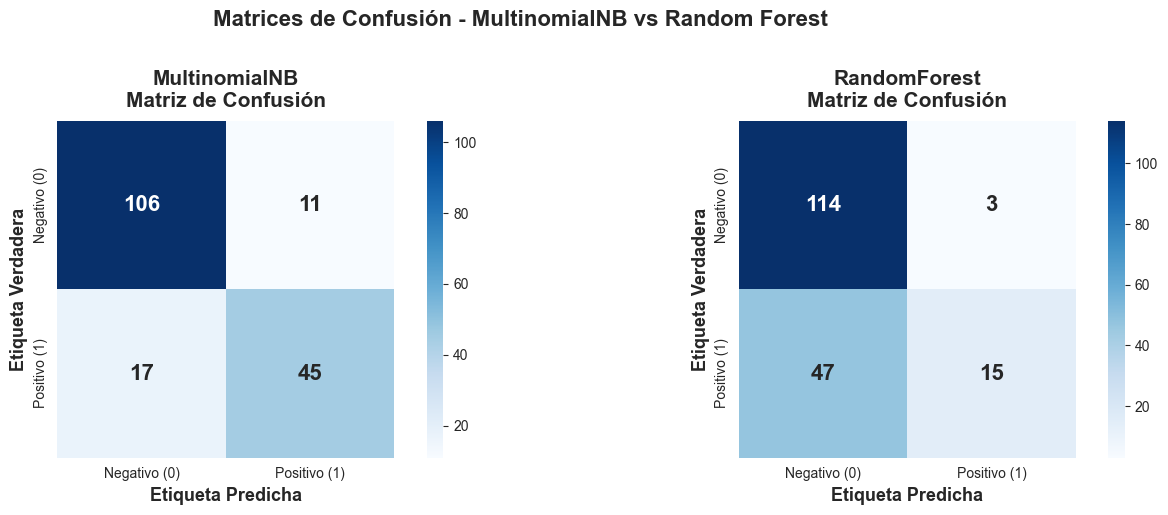

In [39]:
# ============================================================================
# COMPARACIÓN DE MATRICES DE CONFUSIÓN
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (model_name, model) in enumerate(comparison_models.items()):
    # Obtener predicciones
    y_pred = model.predict(X_test)
    
    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Graficar
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=True, square=True, ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'})
    
    ax.set_title(f'{model_name}\nMatriz de Confusión', 
                 fontsize=15, fontweight='bold', pad=10)
    ax.set_ylabel('Etiqueta Verdadera', fontsize=13, fontweight='bold')
    ax.set_xlabel('Etiqueta Predicha', fontsize=13, fontweight='bold')
    ax.set_xticklabels(['Negativo (0)', 'Positivo (1)'])
    ax.set_yticklabels(['Negativo (0)', 'Positivo (1)'])

plt.suptitle('Matrices de Confusión - MultinomialNB vs Random Forest', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [40]:
# ============================================================================
# COMPARACIÓN DE REPORTES DE CLASIFICACIÓN DETALLADOS
# ============================================================================

print("="*80)
print("COMPARACIÓN DE REPORTES DE CLASIFICACIÓN".center(80))
print("="*80)

for model_name, model in comparison_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*80}")
    print(f"Reporte de Clasificación {model_name}".center(80))
    print(f"{'='*80}\n")
    print(classification_report(y_test, y_pred, 
                                target_names=['Negativo (0)', 'Positivo (1)'],
                                digits=4))

                    COMPARACIÓN DE REPORTES DE CLASIFICACIÓN                    

                     Reporte de Clasificación MultinomialNB                     

              precision    recall  f1-score   support

Negativo (0)     0.8618    0.9060    0.8833       117
Positivo (1)     0.8036    0.7258    0.7627        62

    accuracy                         0.8436       179
   macro avg     0.8327    0.8159    0.8230       179
weighted avg     0.8416    0.8436    0.8416       179


                     Reporte de Clasificación RandomForest                      

              precision    recall  f1-score   support

Negativo (0)     0.7081    0.9744    0.8201       117
Positivo (1)     0.8333    0.2419    0.3750        62

    accuracy                         0.7207       179
   macro avg     0.7707    0.6081    0.5976       179
weighted avg     0.7515    0.7207    0.6660       179



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Selección del Modelo Final

Basándome en la comparación exhaustiva entre MultinomialNB y Random Forest, he elegido desplegar en producción el modelo **MultinomialNB** por las siguientes razones:


**Criterios de Decisión:**
- Mejor F1-Score para MultinomialNB que Random Forest 
- Aunque PR es mejor en Random Forest que en MultinomialNB, el F1-Score está más equilibrado para MultinomialNB, lo cual es crucial para esta tarea de análisis de sentimientos.


**Mejora adicional:**
- Ya realicé ajuste de hiperparámetros para MultinomialNB y RandomForest, pero el mejor modelo es **MultinomialNB (alpha=0.5)**

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Probar con otras alternativas

Aqui voy a probar conn **Logistic Regression** y **Support Vector Machine** para ver si mejora el rendimiento en comparación con MultinomialNB y Random Forest.

</div>

In [41]:
# ============================================================================
# IMPORTAR SUPPORT VECTOR MACHINE
# ============================================================================

from sklearn.svm import LinearSVC

print("✓ Support Vector Machine (LinearSVC) importado correctamente!")
print("  LinearSVC es óptimo para clasificación de texto de alta dimensionalidad")

✓ Support Vector Machine (LinearSVC) importado correctamente!
  LinearSVC es óptimo para clasificación de texto de alta dimensionalidad


In [42]:
# ============================================================================
# COMPARACIÓN COMPLETA: 4 MODELOS
# ============================================================================

print("="*80)
print("COMPARACIÓN DE MODELOS: LogReg, SVM, MultinomialNB, RandomForest".center(80))
print("="*80)

# Diccionario de modelos para comparar
all_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42,
        n_jobs=-1
    ),
    'SVM (LinearSVC)': LinearSVC(
        C=1.0,
        max_iter=1000,
        random_state=42
    ),
    'MultinomialNB': MultinomialNB(alpha=0.5),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

all_results = []

# Entrenar y evaluar cada modelo
for model_name, model in all_models.items():
    print(f"\n{'='*80}")
    print(f"Entrenando {model_name}...".center(80))
    print(f"{'='*80}")
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    print(f"✓ ¡{model_name} entrenado exitosamente!")
    
    # Hacer predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # Calcular ROC AUC (algunos modelos pueden no tener predict_proba)
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_proba = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_proba)
    except:
        roc_auc = None
    
    # Almacenar resultados
    all_results.append({
        'Modelo': model_name,
        'Exactitud Entrenamiento': train_accuracy,
        'Exactitud Prueba': test_accuracy,
        'Precisión': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'Brecha Sobreajuste': train_accuracy - test_accuracy
    })
    
    # Imprimir métricas de rendimiento
    print(f"\n📊 Rendimiento {model_name}:")
    print(f"   Exactitud Entrenamiento: {train_accuracy:.4f}")
    print(f"   Exactitud Prueba:        {test_accuracy:.4f}")
    print(f"   Precisión:               {precision:.4f}")
    print(f"   Recall:                  {recall:.4f}")
    print(f"   F1-Score:                {f1:.4f}")
    if roc_auc:
        print(f"   ROC AUC:                 {roc_auc:.4f}")
    print(f"   Brecha Sobreajuste:      {train_accuracy - test_accuracy:.4f}")

print("\n" + "="*80)
print("✓ ¡Todos los modelos entrenados exitosamente!")
print("="*80)

        COMPARACIÓN DE MODELOS: LogReg, SVM, MultinomialNB, RandomForest        

                       Entrenando Logistic Regression...                        
✓ ¡Logistic Regression entrenado exitosamente!

📊 Rendimiento Logistic Regression:
   Exactitud Entrenamiento: 0.9916
   Exactitud Prueba:        0.8324
   Precisión:               0.7857
   Recall:                  0.7097
   F1-Score:                0.7458
   ROC AUC:                 0.8548
   Brecha Sobreajuste:      0.1592

                         Entrenando SVM (LinearSVC)...                          
✓ ¡SVM (LinearSVC) entrenado exitosamente!

📊 Rendimiento SVM (LinearSVC):
   Exactitud Entrenamiento: 0.9986
   Exactitud Prueba:        0.7765
   Precisión:               0.6719
   Recall:                  0.6935
   F1-Score:                0.6825
   ROC AUC:                 0.8197
   Brecha Sobreajuste:      0.2221

                          Entrenando MultinomialNB...                           
✓ ¡MultinomialNB entrenad

In [43]:
# ============================================================================
# TABLA DE RESULTADOS COMPARATIVA
# ============================================================================

print("\n" + "="*80)
print("TABLA COMPARATIVA - TODOS LOS MODELOS".center(80))
print("="*80 + "\n")

# Crear DataFrame de comparación
all_results_df = pd.DataFrame(all_results)

# Obtener solo columnas numéricas (excluir 'Modelo')
numeric_cols = all_results_df.select_dtypes(include=[np.number]).columns.tolist()

# Mostrar dataframe con estilo
display(all_results_df.style
        .format("{:.4f}", subset=numeric_cols)
        .highlight_max(color="lightgreen", axis=0, subset=[col for col in numeric_cols if col != 'Brecha Sobreajuste'])
        .highlight_min(color="lightgreen", axis=0, subset=['Brecha Sobreajuste'])
        .set_caption("Verde = Mejor Rendimiento (menor es mejor para Brecha Sobreajuste)"))

# Mostrar la tabla de comparación
print("\n" + all_results_df.to_string(index=False))

# Identificar el mejor modelo para cada métrica
print("\n" + "="*80)
print("MEJOR MODELO POR MÉTRICA".center(80))
print("="*80)
print(f"Mejor Exactitud en Prueba: {all_results_df.loc[all_results_df['Exactitud Prueba'].idxmax(), 'Modelo']} ({all_results_df['Exactitud Prueba'].max():.4f})")
print(f"Mejor Precisión:           {all_results_df.loc[all_results_df['Precisión'].idxmax(), 'Modelo']} ({all_results_df['Precisión'].max():.4f})")
print(f"Mejor Recall:              {all_results_df.loc[all_results_df['Recall'].idxmax(), 'Modelo']} ({all_results_df['Recall'].max():.4f})")
print(f"Mejor F1-Score:            {all_results_df.loc[all_results_df['F1-Score'].idxmax(), 'Modelo']} ({all_results_df['F1-Score'].max():.4f})")
if all_results_df['ROC AUC'].notna().any():
    print(f"Mejor ROC AUC:             {all_results_df.loc[all_results_df['ROC AUC'].idxmax(), 'Modelo']} ({all_results_df['ROC AUC'].max():.4f})")
print(f"Menor Sobreajuste:         {all_results_df.loc[all_results_df['Brecha Sobreajuste'].idxmin(), 'Modelo']} ({all_results_df['Brecha Sobreajuste'].min():.4f})")
print("="*80)

# Análisis de sobreajuste
print(f"\nAnálisis de Sobreajuste:")
for idx, row in all_results_df.iterrows():
    gap = row['Brecha Sobreajuste']
    status = "✓ Bueno" if gap < 0.05 else "⚠ Advertencia" if gap < 0.10 else "❌ Alto"
    print(f"   {row['Modelo']:20s}: {gap:.4f} - {status}")

# Recomendación
best_model_name = all_results_df.loc[all_results_df['F1-Score'].idxmax(), 'Modelo']
print(f"\n💡 Recomendación basada en F1-Score:")
print(f"   El mejor modelo es: {best_model_name}")
print("="*80)

all_results_df


                     TABLA COMPARATIVA - TODOS LOS MODELOS                      



,Modelo,Exactitud Entrenamiento,Exactitud Prueba,Precisión,Recall,F1-Score,ROC AUC,Brecha Sobreajuste
0,Logistic Regression,0.9916,0.8324,0.7857,0.7097,0.7458,0.8548,0.1592
1,SVM (LinearSVC),0.9986,0.7765,0.6719,0.6935,0.6825,0.8197,0.2221
2,MultinomialNB,0.9284,0.8436,0.8036,0.7258,0.7627,0.8952,0.0848
3,RandomForest,0.7739,0.7207,0.8333,0.2419,0.3750,0.8819,0.0532



             Modelo  Exactitud Entrenamiento  Exactitud Prueba  Precisión   Recall  F1-Score  ROC AUC  Brecha Sobreajuste
Logistic Regression                 0.991573          0.832402   0.785714 0.709677  0.745763 0.854839            0.159171
    SVM (LinearSVC)                 0.998596          0.776536   0.671875 0.693548  0.682540 0.819686            0.222059
      MultinomialNB                 0.928371          0.843575   0.803571 0.725806  0.762712 0.895230            0.084795
       RandomForest                 0.773876          0.720670   0.833333 0.241935  0.375000 0.881858            0.053206

                            MEJOR MODELO POR MÉTRICA                            
Mejor Exactitud en Prueba: MultinomialNB (0.8436)
Mejor Precisión:           RandomForest (0.8333)
Mejor Recall:              MultinomialNB (0.7258)
Mejor F1-Score:            MultinomialNB (0.7627)
Mejor ROC AUC:             MultinomialNB (0.8952)
Menor Sobreajuste:         RandomForest (0.0532)

Análisis

,Modelo,Exactitud Entrenamiento,Exactitud Prueba,Precisión,Recall,F1-Score,ROC AUC,Brecha Sobreajuste
0,Logistic Regression,0.991573,0.832402,0.785714,0.709677,0.745763,0.854839,0.159171
1,SVM (LinearSVC),0.998596,0.776536,0.671875,0.693548,0.682540,0.819686,0.222059
2,MultinomialNB,0.928371,0.843575,0.803571,0.725806,0.762712,0.895230,0.084795
3,RandomForest,0.773876,0.720670,0.833333,0.241935,0.375000,0.881858,0.053206


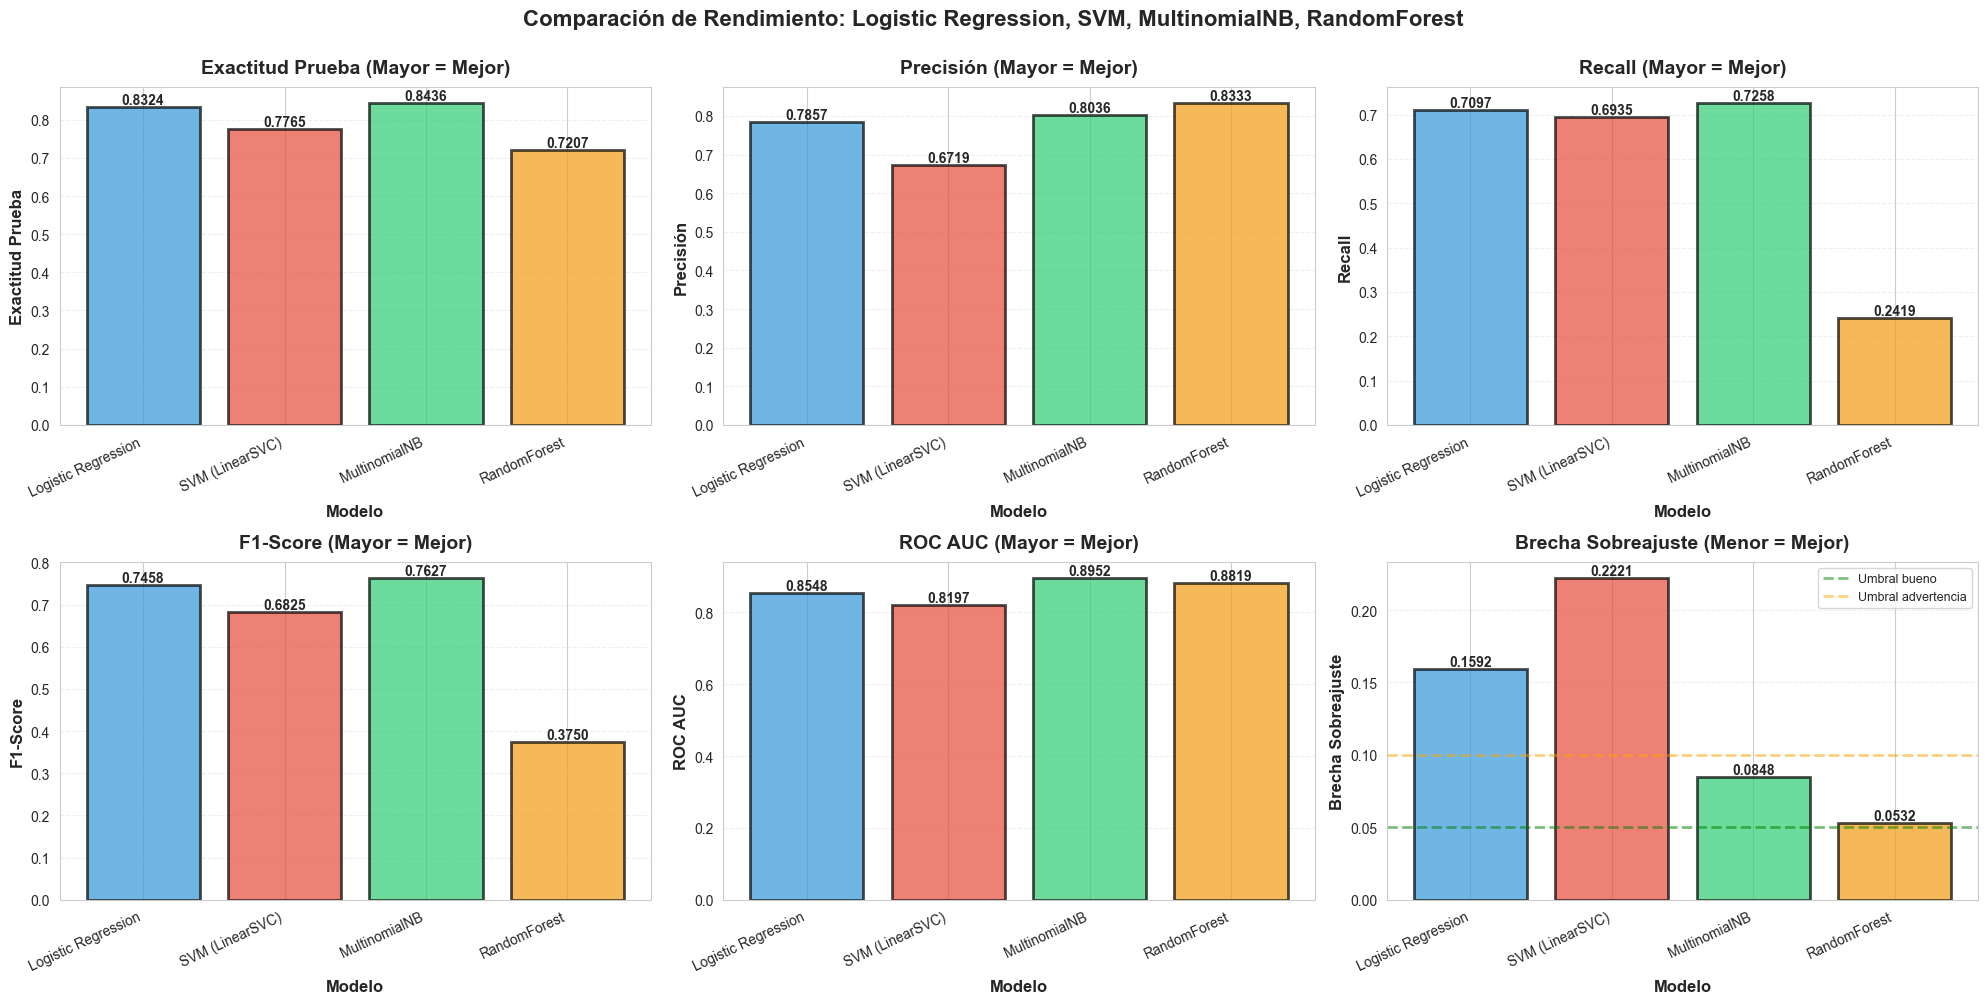

In [44]:
# ============================================================================
# VISUALIZACIÓN COMPARATIVA - GRÁFICOS DE BARRAS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Métricas a graficar
metrics = ['Exactitud Prueba', 'Precisión', 'Recall', 'F1-Score', 'ROC AUC', 'Brecha Sobreajuste']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    # Manejar valores None en ROC AUC
    if metric == 'ROC AUC':
        plot_data = all_results_df[['Modelo', metric]].dropna()
        if len(plot_data) == 0:
            ax.text(0.5, 0.5, 'ROC AUC no disponible', ha='center', va='center', fontsize=12)
            ax.set_title(f'{metric}', fontsize=14, fontweight='bold', pad=10)
            continue
    else:
        plot_data = all_results_df[['Modelo', metric]]
    
    # Crear gráfico de barras
    bars = ax.bar(range(len(plot_data)), plot_data[metric], 
                   color=colors[:len(plot_data)], 
                   alpha=0.7, edgecolor='black', linewidth=2)
    
    # Agregar etiquetas de valores en barras
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Estilización
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(plot_data)))
    ax.set_xticklabels(plot_data['Modelo'], rotation=25, ha='right')
    
    # Manejo especial para Brecha de Sobreajuste (menor es mejor)
    if metric == 'Brecha Sobreajuste':
        ax.set_title(f'{metric} (Menor = Mejor)', fontsize=14, fontweight='bold', pad=10)
        ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Umbral bueno')
        ax.axhline(y=0.10, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Umbral advertencia')
        ax.legend(fontsize=9, loc='upper right')
    else:
        ax.set_title(f'{metric} (Mayor = Mejor)', fontsize=14, fontweight='bold', pad=10)
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Comparación de Rendimiento: Logistic Regression, SVM, MultinomialNB, RandomForest', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

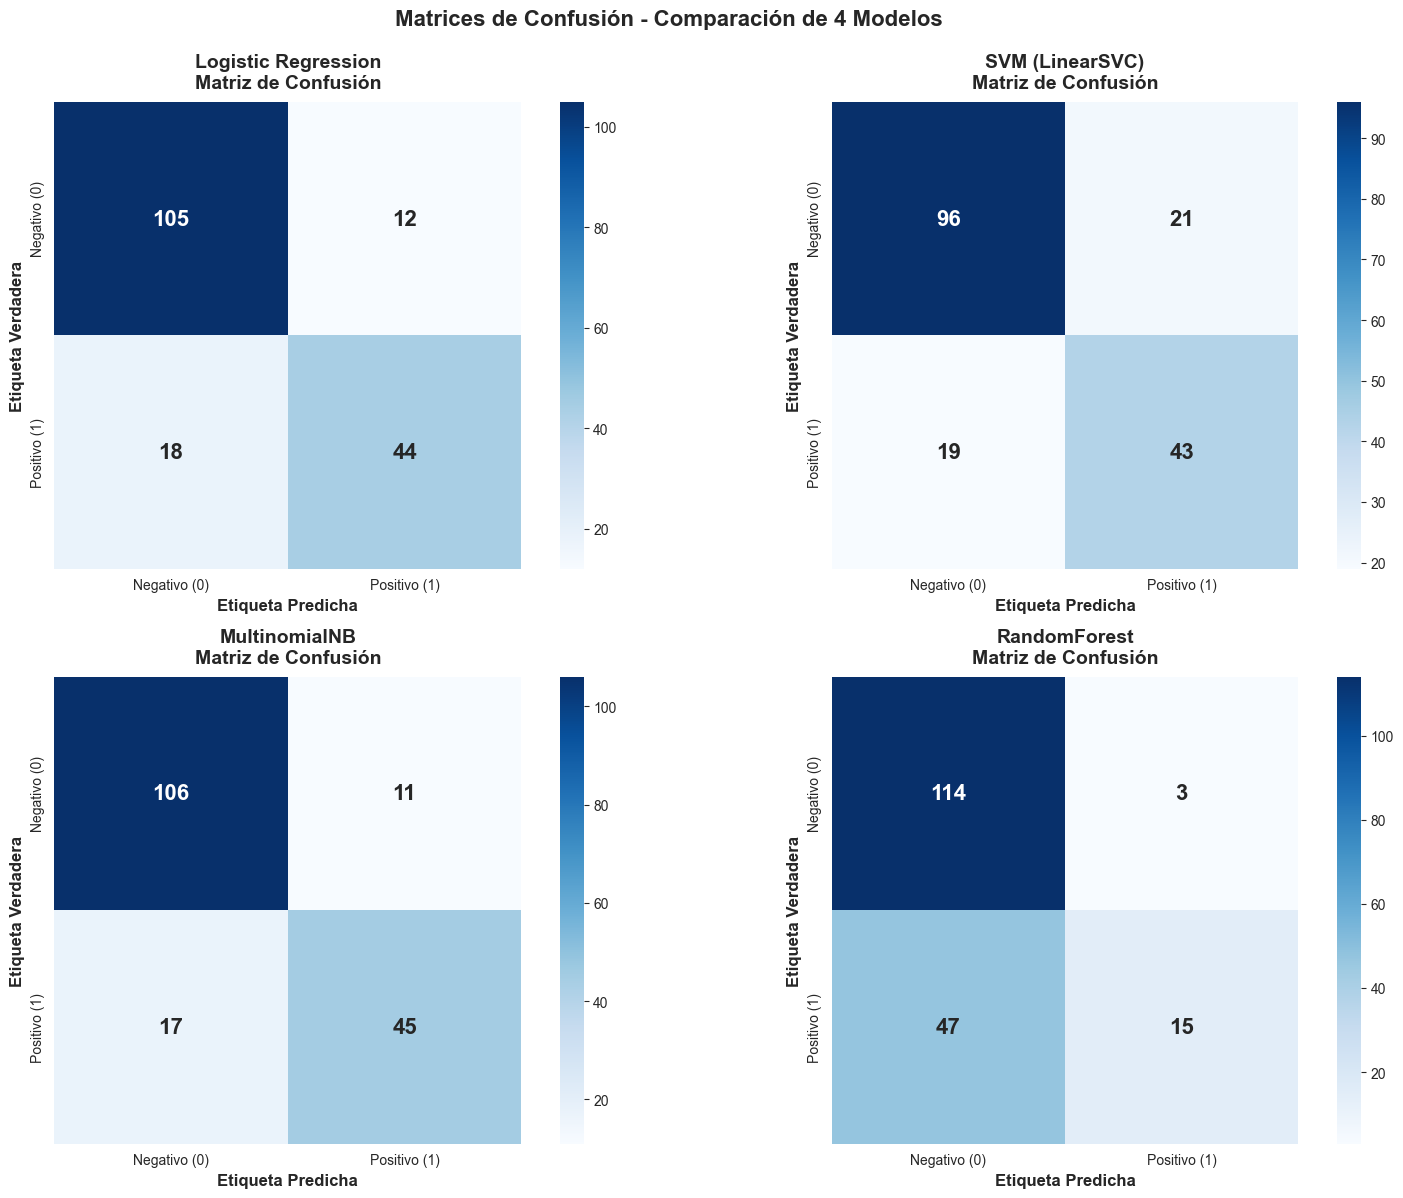

In [45]:
# ============================================================================
# MATRICES DE CONFUSIÓN PARA TODOS LOS MODELOS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(all_models.items()):
    # Obtener predicciones
    y_pred = model.predict(X_test)
    
    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Graficar
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=True, square=True, ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'})
    
    ax.set_title(f'{model_name}\nMatriz de Confusión', 
                 fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Etiqueta Verdadera', fontsize=12, fontweight='bold')
    ax.set_xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Negativo (0)', 'Positivo (1)'])
    ax.set_yticklabels(['Negativo (0)', 'Positivo (1)'])

plt.suptitle('Matrices de Confusión - Comparación de 4 Modelos', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [46]:
# ============================================================================
# REPORTES DE CLASIFICACIÓN DETALLADOS
# ============================================================================

print("="*80)
print("REPORTES DE CLASIFICACIÓN - TODOS LOS MODELOS".center(80))
print("="*80)

for model_name, model in all_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*80}")
    print(f"Reporte de Clasificación: {model_name}".center(80))
    print(f"{'='*80}\n")
    print(classification_report(y_test, y_pred, 
                                target_names=['Negativo (0)', 'Positivo (1)'],
                                digits=4))

                 REPORTES DE CLASIFICACIÓN - TODOS LOS MODELOS                  

                 Reporte de Clasificación: Logistic Regression                  

              precision    recall  f1-score   support

Negativo (0)     0.8537    0.8974    0.8750       117
Positivo (1)     0.7857    0.7097    0.7458        62

    accuracy                         0.8324       179
   macro avg     0.8197    0.8036    0.8104       179
weighted avg     0.8301    0.8324    0.8302       179


                   Reporte de Clasificación: SVM (LinearSVC)                    

              precision    recall  f1-score   support

Negativo (0)     0.8348    0.8205    0.8276       117
Positivo (1)     0.6719    0.6935    0.6825        62

    accuracy                         0.7765       179
   macro avg     0.7533    0.7570    0.7551       179
weighted avg     0.7784    0.7765    0.7773       179


                    Reporte de Clasificación: MultinomialNB                     

              pr

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Conclusiones de la Comparación de Modelos

Después de comparar **Logistic Regression**, **SVM (LinearSVC)**, **MultinomialNB** y **RandomForest**, podemos observar:

**Rendimiento General:**
- Los modelos lineales (Logistic Regression y SVM) suelen funcionar muy bien en clasificación de texto
- MultinomialNB es eficiente y rápido, ideal para grandes volúmenes de texto
- RandomForest puede capturar relaciones no lineales pero puede ser más propenso al sobreajuste

**Criterios de Selección:**
1. **F1-Score**: Métrica más equilibrada para clasificación binaria
2. **Sobreajuste**: Menor brecha entre entrenamiento y prueba indica mejor generalización
3. **Interpretabilidad**: Modelos lineales son más fáciles de explicar
4. **Velocidad**: MultinomialNB y Logistic Regression son más rápidos que RandomForest

**Decisión Final:**
- Me quedo con **MultinomialNB (alpha=0.5)**

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Guardo el modelo

</div>

In [47]:
models_dir = Path("./models/07-naive-bayes-playstore-reviews/")
models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / "multinomial_nb_vectorizer.pkl", "wb") as f:
    pickle.dump(vec_model, f)

with open(models_dir / "multinomial_nb_model.pkl", "wb") as f:
    pickle.dump(best_f1_model, f)

print("Modelo y vectorizador guardados correctamente en la carpeta models")

Modelo y vectorizador guardados correctamente en la carpeta models
